In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_features = pd.read_csv('dengue_features_train.csv')
test_features =  pd.read_csv('dengue_features_test.csv')
train_labels = pd.read_csv('dengue_labels_train.csv')


In [2]:
train = train_features.merge(
    train_labels,
    on= ['city', 'year', 'weekofyear'],
    how='left'
)
train['week_start_date'] = pd.to_datetime(train['week_start_date'])
test_features['week_start_date'] = pd.to_datetime(test_features['week_start_date'])
train = train.sort_values(['city', 'year', 'weekofyear']).reset_index(drop=True)
test_features = test_features.sort_values(['city', 'year', 'weekofyear']).reset_index(drop=True)
train_sj = train[train['city'] == 'sj'].copy()
train_iq = train[train['city'] == 'iq'].copy()
test_sj = test_features[test_features['city'] == 'sj'].copy()
test_iq = test_features[test_features['city'] == 'iq'].copy()

In [3]:
for window in [4,8,12]:
    train[f'rolling_mean_{window}'] = (
        train.groupby('city')['total_cases']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

for window in [4,8]:
    train[f'rolling_max_window'] = (
        train.groupby('city')['total_cases']
        .transform(lambda x: x.shift(1).rolling(window).max())
    )
train = train.dropna().reset_index(drop=True)
train['trend'] = train.groupby('city').cumcount()
train['week_sin'] = np.sin(2*np.pi*train['weekofyear'] / 52)
train['week_cos'] = np.sin(2*np.pi*train['weekofyear'] / 52)

In [4]:
for lag in range (1,17):
    train[f'lag_{lag}'] = train.groupby('city')['total_cases'].shift(lag)

In [5]:
drop_cols = ['year', 'weekofyear']
train = train.drop(columns=drop_cols)

Dengue cases are highly autocorrelated. Creating lag features allows the model to capture temporal dependency and outbreak persistence, effectively transforming the regression into an autoregressive time-series model.

In [6]:
train['rolling_mean_4'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)
train['rolling_mean_8'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x:x.shift(1).rolling(8).mean())
)
train['rolling_std_4'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x: x.shift(1).rolling(4).std())
)
train['rolling_max_4'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x: x.shift(1).rolling(4).max())
)
train = train.dropna().reset_index(drop=True)
train['rolling_std_4'].head(20)

0     0.00000
1     0.00000
2     0.00000
3     0.00000
4     0.00000
5     0.00000
6     0.00000
7     0.00000
8     0.00000
9     0.00000
10    0.00000
11    0.00000
12    0.00000
13    0.50000
14    0.50000
15    0.50000
16    0.50000
17    0.50000
18    0.57735
19    0.57735
Name: rolling_std_4, dtype: float64

In [7]:
split_index_sj = train_sj.shape[0] - 52
train_sj_train = train_sj.iloc[:split_index_sj]
train_sj_Val = train_sj.iloc[split_index_sj:]


In [8]:
features = [col for col in train_sj.columns
            if col not in ['city' ,'week_start_date', 'total_cases']]

X_sj_train = train_sj_train[features]
y_sj_train = train_sj_train['total_cases']
X_sj_val = train_sj_Val[features]
y_sj_val = train_sj_Val['total_cases']

In [9]:
split_index_iq = train_iq.shape[0] - 52
train_iq_train = train_iq.iloc[:split_index_iq]
train_iq_Val = train_iq.iloc[split_index_iq:]
features_iq = [col for col in train_iq.columns
            if col not in ['city', 'week_start_date', 'total_cases']]

X_iq_train = train_iq_train[features_iq]
y_iq_train = train_iq_train['total_cases']
X_iq_val = train_iq_Val[features_iq]
y_iq_val = train_iq_Val['total_cases']

In [10]:
print(train_sj_train.columns)
print(features)

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases'],
      dtype='str')
['year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humid

In [11]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
model_iq = XGBRegressor(
    n_estimators = 1200,
    learning_rate = 0.03,
    max_depth = 6,
    subsample = 0.9,
    colsample_bytree = 0.9,
    objective = 'count:poisson',
    random_state = 42 
)
model_iq.fit(X_iq_train, y_iq_train)
y_pred_iq = model_iq.predict(X_iq_val)
mae_iq = mean_absolute_error(y_iq_val, y_pred_iq)
print('Iquitos Mean Absolute Error: ', mae_iq)

Iquitos Mean Absolute Error:  3.781120777130127


Text(0.5, 1.0, 'Iquitos - Actual vs Prediction')

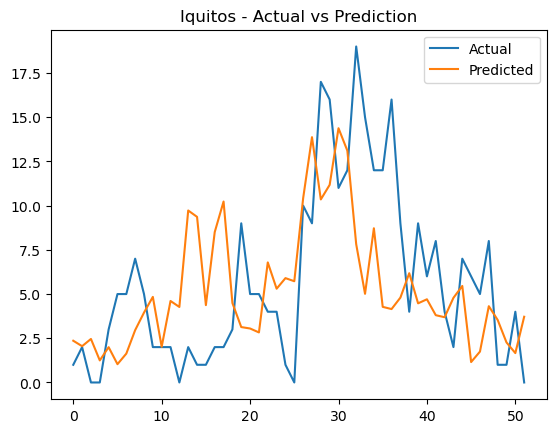

In [12]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(12,8))
plt.plot(y_iq_val.values, label = 'Actual')
plt.plot(y_pred_iq, label = 'Predicted')
plt.legend()
plt.title('Iquitos - Actual vs Prediction')

In [13]:
train_sj_train.columns

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases'],
      dtype='str')